<center><b>DS Project : Australia Weather</b></center>

Légende couleurs:<br>
- <font color="green">Action réalisée</font> <font size=2>(conserver l'info pour traçabilité)</font><br>
- <font color="orange">Action à réaliser</font> <br>
- <font color="red">Décision à prendre</font>

Ressources:<br>
- Site Gouv Australia - graphique pluviométrie 2024 : https://www.bom.gov.au/climate/current/annual/aus/#tabs=Rainfall
- Site Gouv Australia - Résumé température/pluie pour différentes villes 2024 : https://www.bom.gov.au/climate/current/annual/aus/#tabs=Overview
- Météociel Archive: La pression atmosphérique minimale en Australie a été mesurée à environ 868,5 hPa lors du cyclone Monica, qui a frappé au nord de Maningrida, en Australie, le 23 avril 2006
- Météociel Archive: La pression atmosphérique maximale en Australie se produit généralement au niveau de la mer, où la pression est d'environ 1013,25 hPa (ou 1 atm). Cependant, certaines régions, comme certaines côtes du Queensland, peuvent atteindre des pressions plus élevées, atteignant même des niveaux supérieurs à 1050 hPa



Rappel des unités du DataSet:<br>
- MinTemp & MaxTemp : Temperature in degrees celsius
- Rainfall : The amount of rainfall recorded for the day in mm
- Evaporation : The so-called Class A pan evaporation (mm) in the 24 hours to 9am
- Sunshine : The number of hours of bright sunshine in the day.
- WindGustDir: The direction of the strongest wind gust in the 24 hours to midnight
- WindGustSpeed : The speed (km/h) of the strongest wind gust in the 24 hours to midnight

<center><b><font color="skyblue">Initialisation du projet: Database, librairies et première visualisation</font></b></center>

In [2]:
# import librairie pour l'utilisation des adresses
import os.path
# import librairie traitement de données
import pandas as pd
import numpy as np
from datetime import date
# import librairie modélisation de graphique
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [3]:
df = pd.read_csv("../data/weatherAUS.csv")
df.head(3)

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,...,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,...,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,No


In [4]:
display(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145460 entries, 0 to 145459
Data columns (total 23 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Date           145460 non-null  object 
 1   Location       145460 non-null  object 
 2   MinTemp        143975 non-null  float64
 3   MaxTemp        144199 non-null  float64
 4   Rainfall       142199 non-null  float64
 5   Evaporation    82670 non-null   float64
 6   Sunshine       75625 non-null   float64
 7   WindGustDir    135134 non-null  object 
 8   WindGustSpeed  135197 non-null  float64
 9   WindDir9am     134894 non-null  object 
 10  WindDir3pm     141232 non-null  object 
 11  WindSpeed9am   143693 non-null  float64
 12  WindSpeed3pm   142398 non-null  float64
 13  Humidity9am    142806 non-null  float64
 14  Humidity3pm    140953 non-null  float64
 15  Pressure9am    130395 non-null  float64
 16  Pressure3pm    130432 non-null  float64
 17  Cloud9am       89572 non-null

None

Première analyse:<br>
- On constate la présence de valeurs manquantes --> <font color="green">déterminer l'importance par colonne</font>
- La colonne date est en type Objet --> <font color="green">à passer en type Date pour utilisation</font>
- Les colonnes Location, WindDir9am et WindDir3pm sont en object --> <font color="green">à passer en string</font>
- Les colonnes RainToday et RainTomorrow sont en object --> <font color="green">à passer en float avec un remplacement des valeurs No et Yes par 0 et 1</font><br>
Pour finir, on constate que les valeurs suivant les colonnes ont des échelles très différentes --> <font color="orange">il faudra normaliser les valeurs pour les exploiter lors du ML</font>

In [5]:
# passage de la colonne date en format datetime
df['Date'] = pd.to_datetime(df['Date'])

In [6]:
# passage des colonnes Location, WindGustDir, WinDir9am et WindDir3pm en string
df['Location'] = df['Location'].astype(str)
df['WindGustDir'] = df['WindGustDir'].astype(str)
df['WindDir9am'] = df['WindDir9am'].astype(str)
df['WindDir3pm'] = df['WindDir3pm'].astype(str)

In [7]:
# passage des colonnes RainToday et RainTomorrow en valeurs 0 ou 1
df['RainToday'] = df['RainToday'].replace({'No' : 0, 'Yes' : 1})
df['RainTomorrow'] = df['RainTomorrow'].replace({'No' : 0, 'Yes' : 1})

C:\Users\guill\AppData\Local\Temp\ipykernel_16668\835643962.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['RainToday'] = df['RainToday'].replace({'No' : 0, 'Yes' : 1})
C:\Users\guill\AppData\Local\Temp\ipykernel_16668\835643962.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['RainTomorrow'] = df['RainTomorrow'].replace({'No' : 0, 'Yes' : 1})


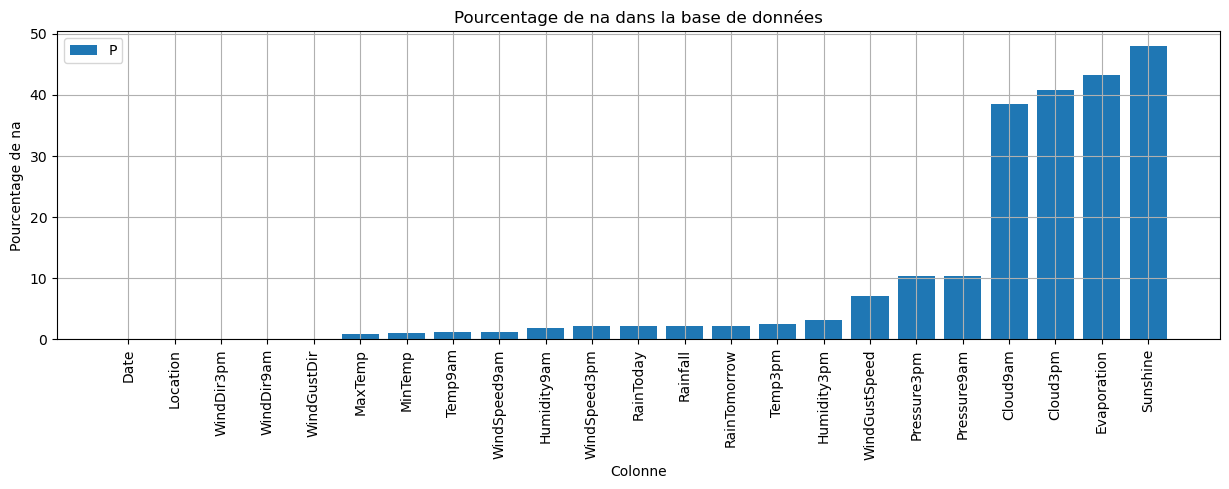

In [8]:
# calcul en pourcentage des valeurs manquantes pour chaque colonne du df pour modélisation dans un graphique
na_counts = round(df.isna().sum()/len(df)*100,1)

# Création d'un DataFrame à partir des résultats
emptiness = pd.DataFrame({'column_name': na_counts.index, 'percent_na': na_counts.values})
emptiness_sorted = emptiness.sort_values(by = "percent_na", ascending = True)

# Modélisation graphique des % de na
plt.figure(figsize=(15,4))
plt.grid()
plt.bar(x = emptiness_sorted.column_name, height = emptiness_sorted.percent_na)
plt.xlabel('Colonne')
plt.xticks(rotation=90)
plt.ylabel('Pourcentage de na')
plt.title('Pourcentage de na dans la base de données')
plt.legend('Pourcentage de na');

Analyse:<br>
On constate que les colonnes Cloud3pm, Cloud9PM, Evaporation et Sunshine ont le plus fort taux de valeurs manquantes.
Les autres colonnes sont à ~<10% de na.<br>
<font color="red"> --> Décision à prendre : suppression des colonnes si estimées non nécessaires/exploitables ou compléter avec des valeurs par défaut basées sur les autres colonnes.</font>

<center><b><font color="skyblue">Analyse de la distribution des valeurs</font></b></center>

In [9]:
# Création d'une colonne année
df['annee'] = df['Date'].dt.year
# Liste des valeurs uniques des colonnes Location, année, WindGustDir, WindDir9am, WindDir3pm 
display('Les années concernées par l étude sont:', np.sort(df['annee'].unique()))
display('Les localités concernées par l étude sont:', np.sort(df['Location'].unique()))
display('Les WindGustDir concernées par l étude sont:', np.sort(df['WindGustDir'].unique()))
display('Les WindDir9am concernées par l étude sont:', np.sort(df['WindDir9am'].unique()))
display('Les WindDir3pm concernées par l étude sont:', np.sort(df['WindDir3pm'].unique()))

'Les années concernées par l étude sont:'

array([2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017],
      dtype=int32)

'Les localités concernées par l étude sont:'

array(['Adelaide', 'Albany', 'Albury', 'AliceSprings', 'BadgerysCreek',
       'Ballarat', 'Bendigo', 'Brisbane', 'Cairns', 'Canberra', 'Cobar',
       'CoffsHarbour', 'Dartmoor', 'Darwin', 'GoldCoast', 'Hobart',
       'Katherine', 'Launceston', 'Melbourne', 'MelbourneAirport',
       'Mildura', 'Moree', 'MountGambier', 'MountGinini', 'Newcastle',
       'Nhil', 'NorahHead', 'NorfolkIsland', 'Nuriootpa', 'PearceRAAF',
       'Penrith', 'Perth', 'PerthAirport', 'Portland', 'Richmond', 'Sale',
       'SalmonGums', 'Sydney', 'SydneyAirport', 'Townsville',
       'Tuggeranong', 'Uluru', 'WaggaWagga', 'Walpole', 'Watsonia',
       'Williamtown', 'Witchcliffe', 'Wollongong', 'Woomera'],
      dtype=object)

'Les WindGustDir concernées par l étude sont:'

array(['E', 'ENE', 'ESE', 'N', 'NE', 'NNE', 'NNW', 'NW', 'S', 'SE', 'SSE',
       'SSW', 'SW', 'W', 'WNW', 'WSW', 'nan'], dtype=object)

'Les WindDir9am concernées par l étude sont:'

array(['E', 'ENE', 'ESE', 'N', 'NE', 'NNE', 'NNW', 'NW', 'S', 'SE', 'SSE',
       'SSW', 'SW', 'W', 'WNW', 'WSW', 'nan'], dtype=object)

'Les WindDir3pm concernées par l étude sont:'

array(['E', 'ENE', 'ESE', 'N', 'NE', 'NNE', 'NNW', 'NW', 'S', 'SE', 'SSE',
       'SSW', 'SW', 'W', 'WNW', 'WSW', 'nan'], dtype=object)

Analyse:<br>
Il n'y a pas de mauvaise valeur à corriger dans les colonnes ci-dessus (pas de faute frappe ...)<br>
<font color="red"> Garde-t-on une différence de localité entre les villes et les aéroports de ces villes? --> 'Melbourne', 'MelbourneAirport', 'Perth', 'PerthAirport', 'Sydney', 'SydneyAirport'</font>

<Figure size 1500x1500 with 0 Axes>

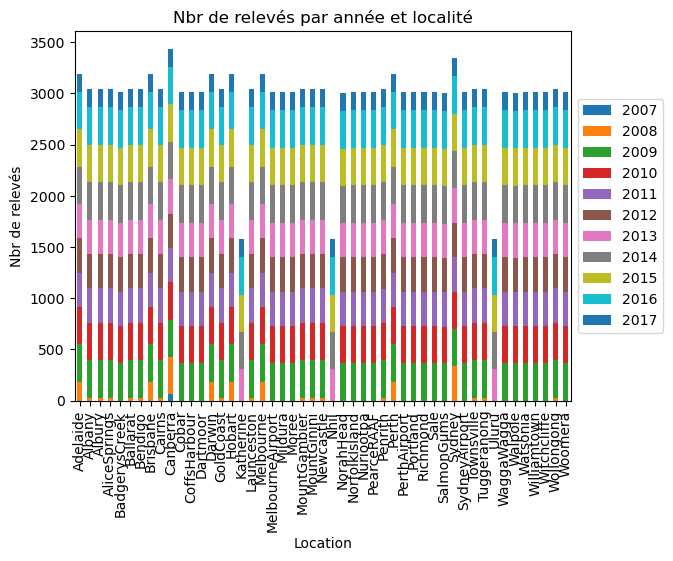

In [10]:
# Réalisation d'un crosstab pour visualiser les relevés par années et localités
ct = pd.crosstab(df['Location'], df['annee'])
# Graphique en barres empilées
plt.figure(figsize=(15,15))
ct.plot(kind='bar', stacked=True, title="Nbr de relevés par année et localité", width = 0.5)
plt.ylabel("Nbr de relevés")
plt.legend(loc="center left", bbox_to_anchor=(1, 0.5), borderaxespad=0.5);

Analyse:<br>
On peut se poser la question de savoir si l'on conserve les localisations "Katherine", "Nhil", "Uluru" car nous n'avons des données que pour les années 2013 à 2017 mais pas de 2007 à 2016<br>
De même les relevés des années 2007 et 2008 semblent être peu nombreux et même inexistant pour beaucoup de localisations<br>
<font color="red">Garde-t-on les annnées 2007 - 2008 et les villes "Katherine", "Nhil", "Uluru"?</font>

<center><font color="skyblue"><b>Gestion des variables numériques</b></font></center>

In [11]:
df.describe()

,Date,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow,annee
count,145460,143975.000000,144199.000000,142199.000000,82670.000000,75625.000000,135197.000000,143693.000000,142398.000000,142806.000000,140953.000000,130395.00000,130432.000000,89572.000000,86102.000000,143693.000000,141851.00000,142199.000000,142193.000000,145460.000000
mean,2013-04-04 21:08:51.907053568,12.194034,23.221348,2.360918,5.468232,7.611178,40.035230,14.043426,18.662657,68.880831,51.539116,1017.64994,1015.255889,4.447461,4.509930,16.990631,21.68339,0.224193,0.224181,2012.769751
min,2007-11-01 00:00:00,-8.500000,-4.800000,0.000000,0.000000,0.000000,6.000000,0.000000,0.000000,0.000000,0.000000,980.50000,977.100000,0.000000,0.000000,-7.200000,-5.40000,0.000000,0.000000,2007.000000
25%,2011-01-11 00:00:00,7.600000,17.900000,0.000000,2.600000,4.800000,31.000000,7.000000,13.000000,57.000000,37.000000,1012.90000,1010.400000,1.000000,2.000000,12.300000,16.60000,0.000000,0.000000,2011.000000
50%,2013-06-02 00:00:00,12.000000,22.600000,0.000000,4.800000,8.400000,39.000000,13.000000,19.000000,70.000000,52.000000,1017.60000,1015.200000,5.000000,5.000000,16.700000,21.10000,0.000000,0.000000,2013.000000
75%,2015-06-14 00:00:00,16.900000,28.200000,0.800000,7.400000,10.600000,48.000000,19.000000,24.000000,83.000000,66.000000,1022.40000,1020.000000,7.000000,7.000000,21.600000,26.40000,0.000000,0.000000,2015.000000
max,2017-06-25 00:00:00,33.900000,48.100000,371.000000,145.000000,14.500000,135.000000,130.000000,87.000000,100.000000,100.000000,1041.00000,1039.600000,9.000000,9.000000,40.200000,46.70000,1.000000,1.000000,2017.000000
std,NaN,6.398495,7.119049,8.478060,4.193704,3.785483,13.607062,8.915375,8.809800,19.029164,20.795902,7.10653,7.037414,2.887159,2.720357,6.488753,6.93665,0.417051,0.417043,2.537684


Analyse:<br>
- Les valeurs de pressions sont comprises entre 850  et 1050hPa (voir ressource en début de notebook)
- Les températures, vitesses de vent, luminosité, humidité, ennuagement sont cohérents au vue des unités de chaque variable
- La pluviométrie (rainfall) est à contrôler au niveau distribution

In [12]:
# création de la liste des colonnes numériques
numerical_col = ['MinTemp','MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine', 'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm', 'Temp9am', 'Temp3pm']

Boxplot pour l année 2007


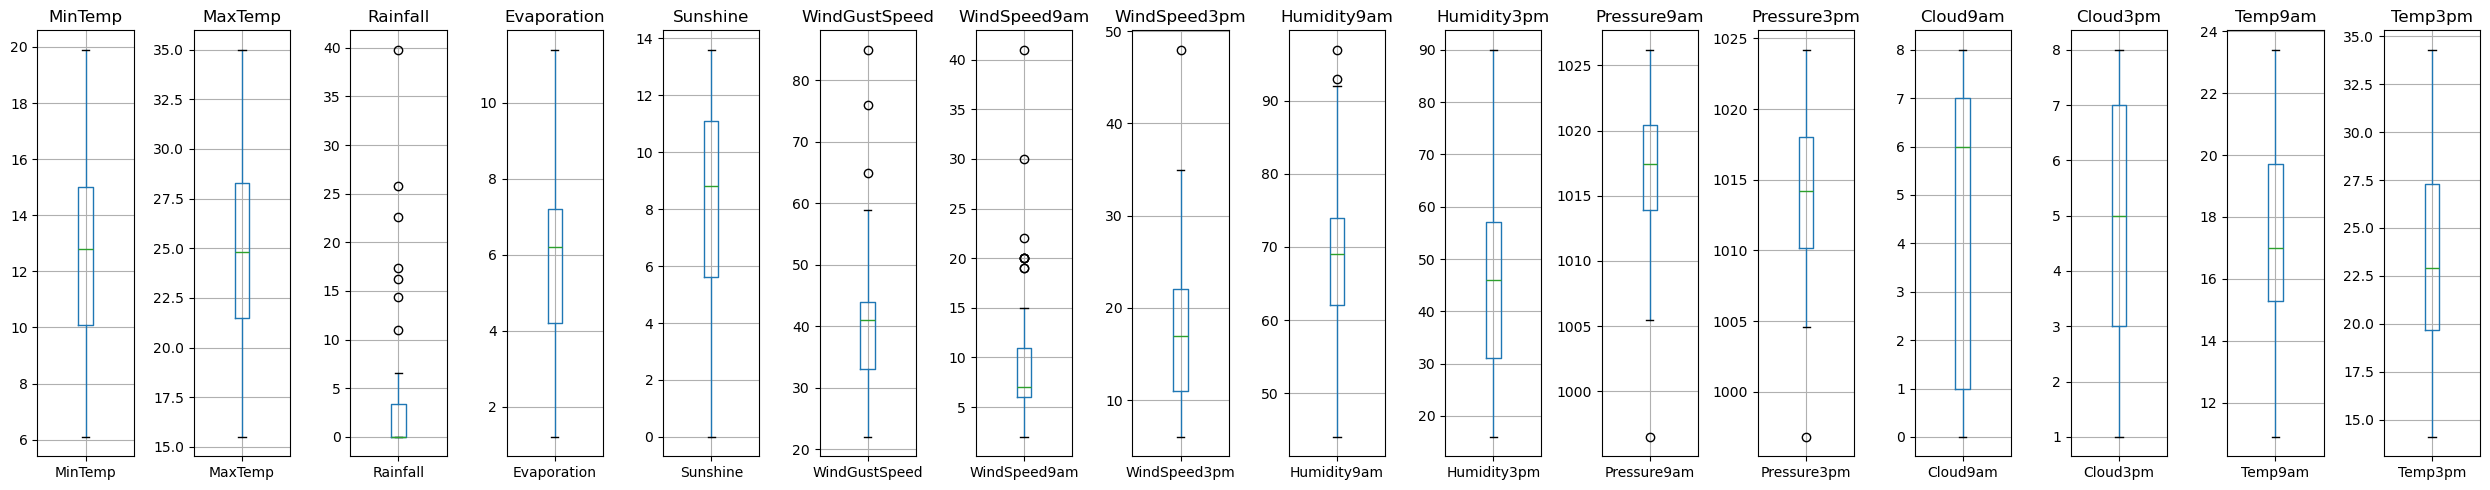

Boxplot pour l année 2008


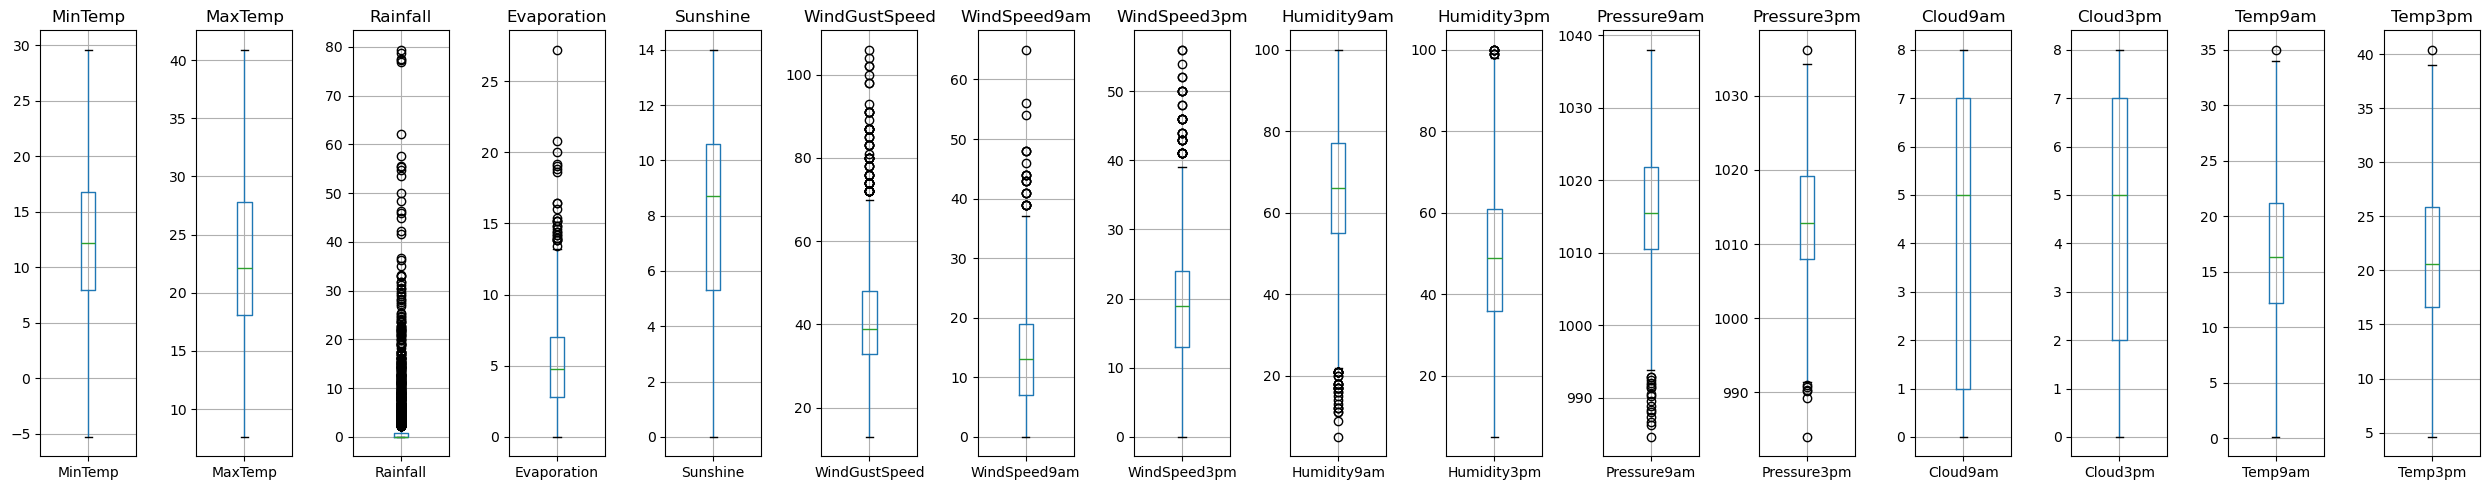

Boxplot pour l année 2009


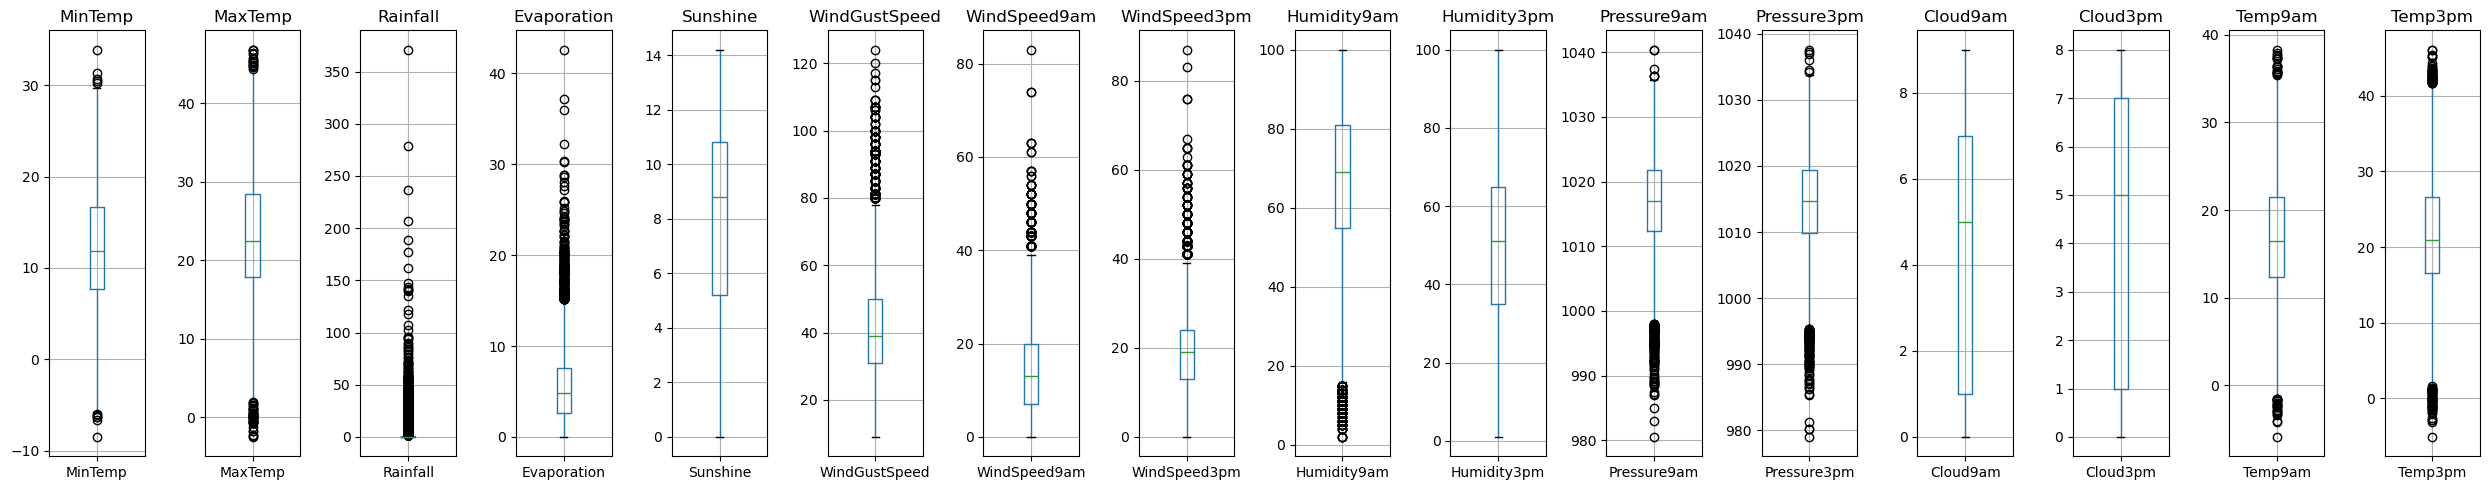

Boxplot pour l année 2010


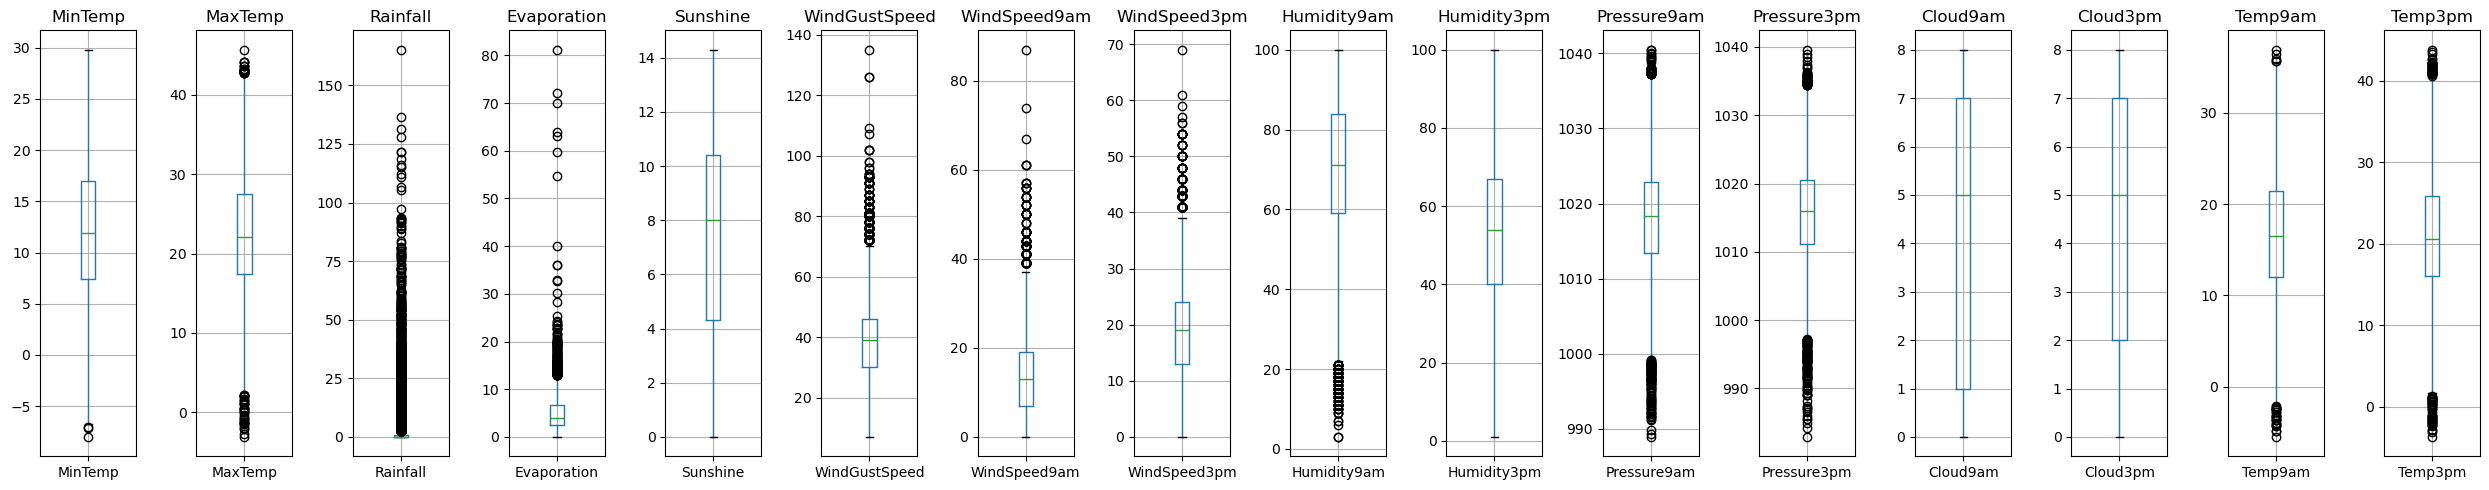

Boxplot pour l année 2011


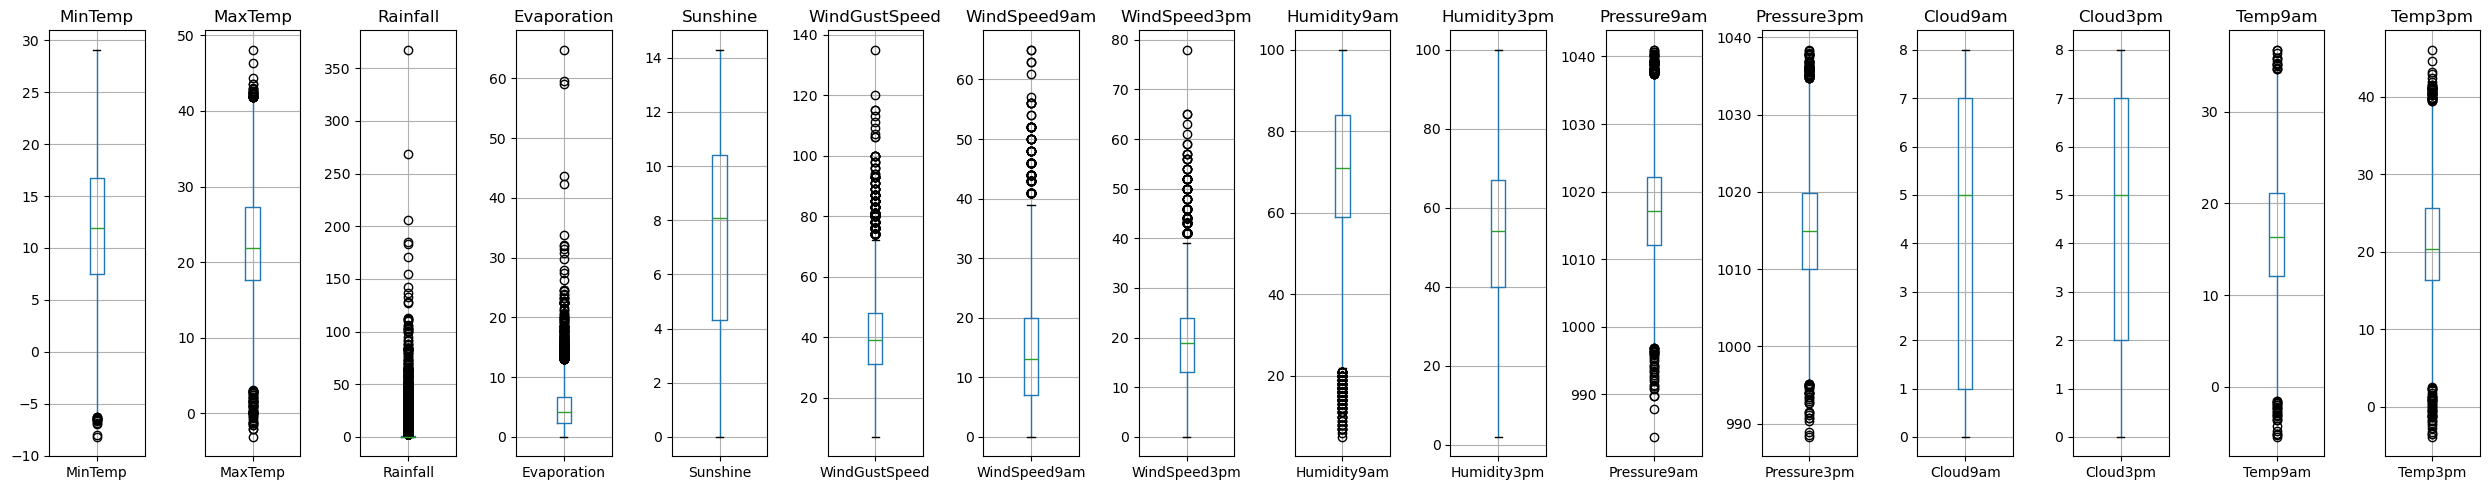

Boxplot pour l année 2012


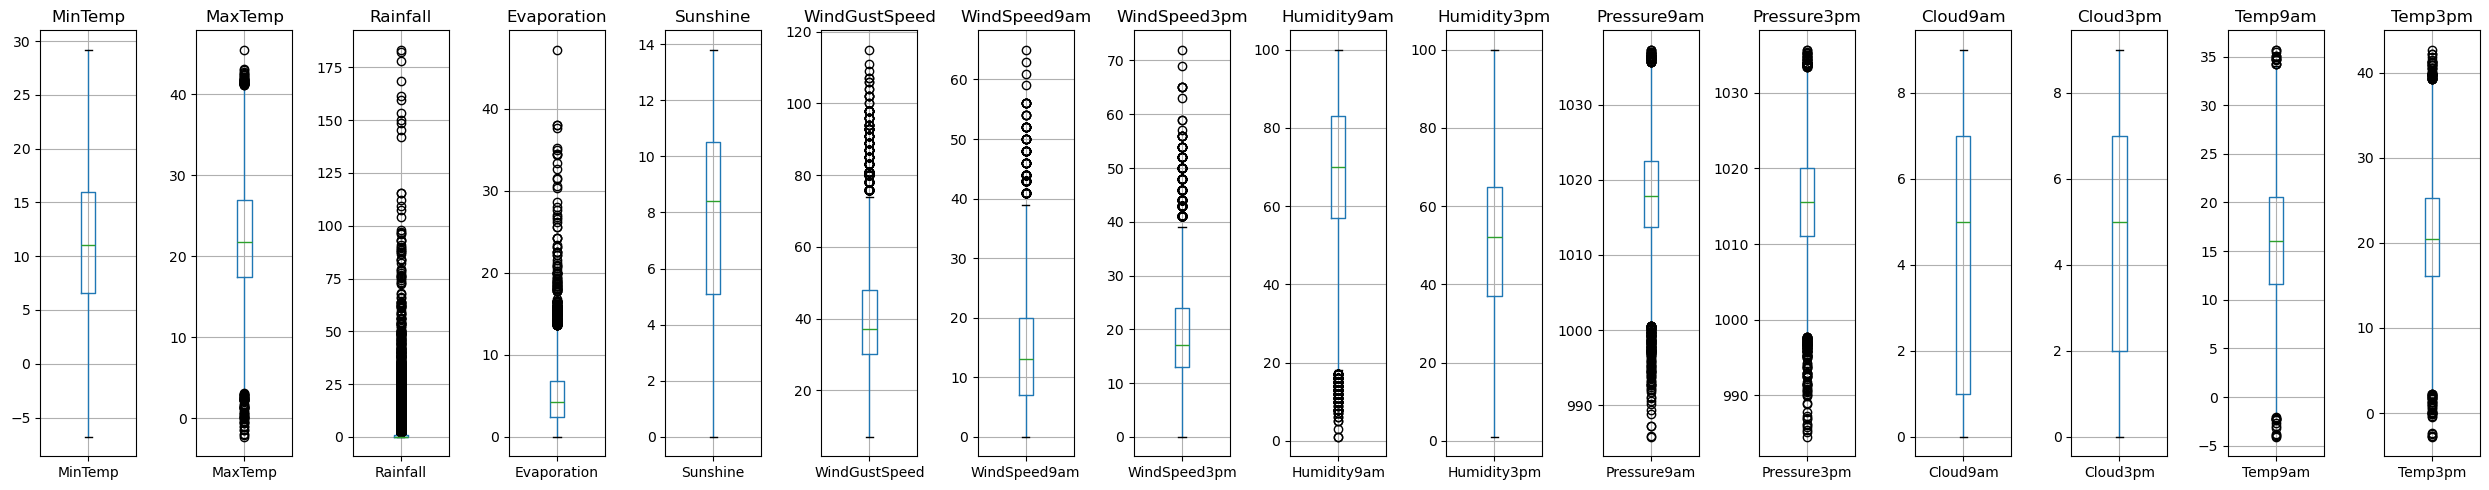

Boxplot pour l année 2013


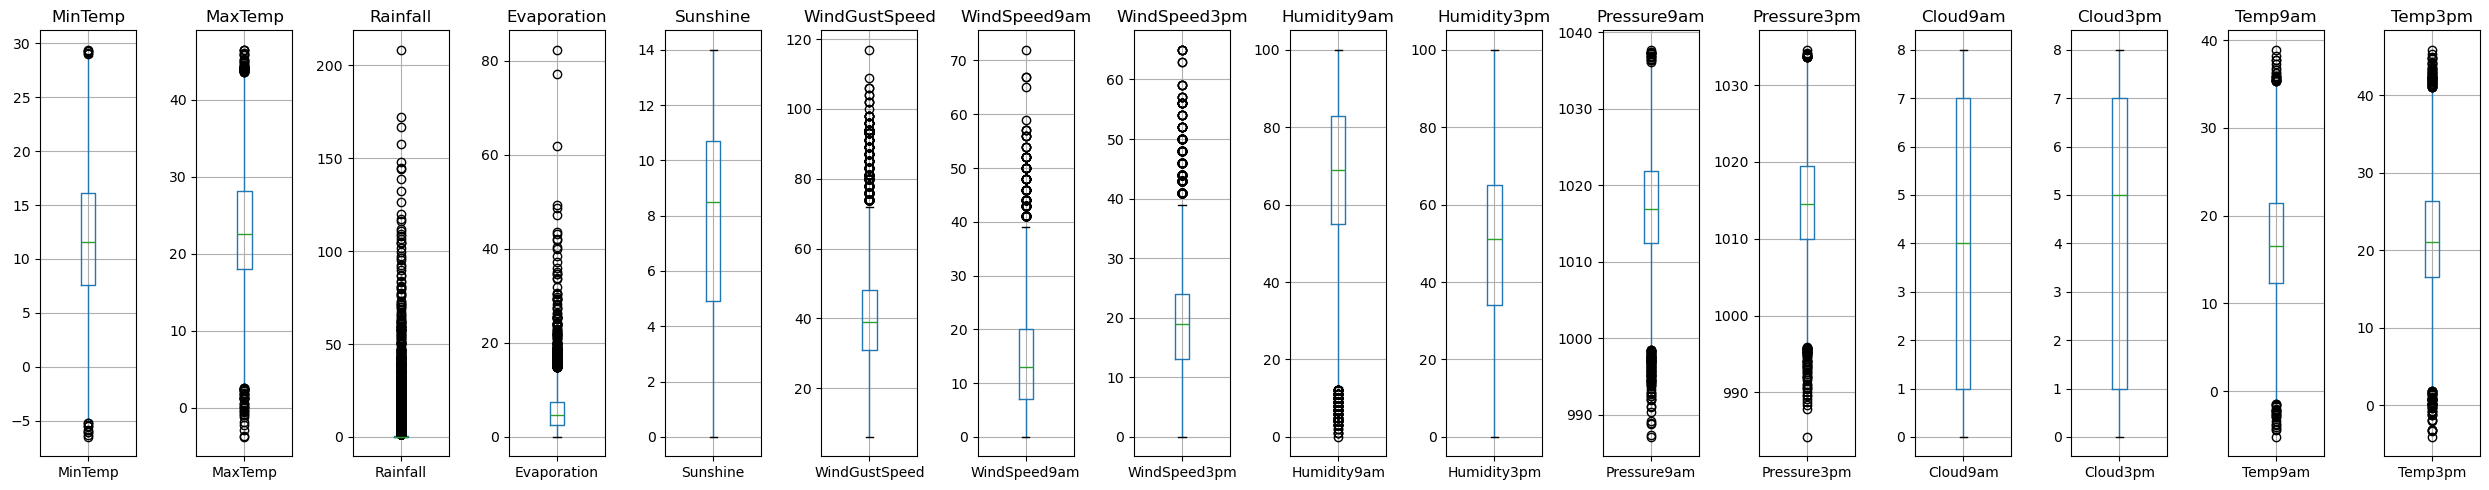

Boxplot pour l année 2014


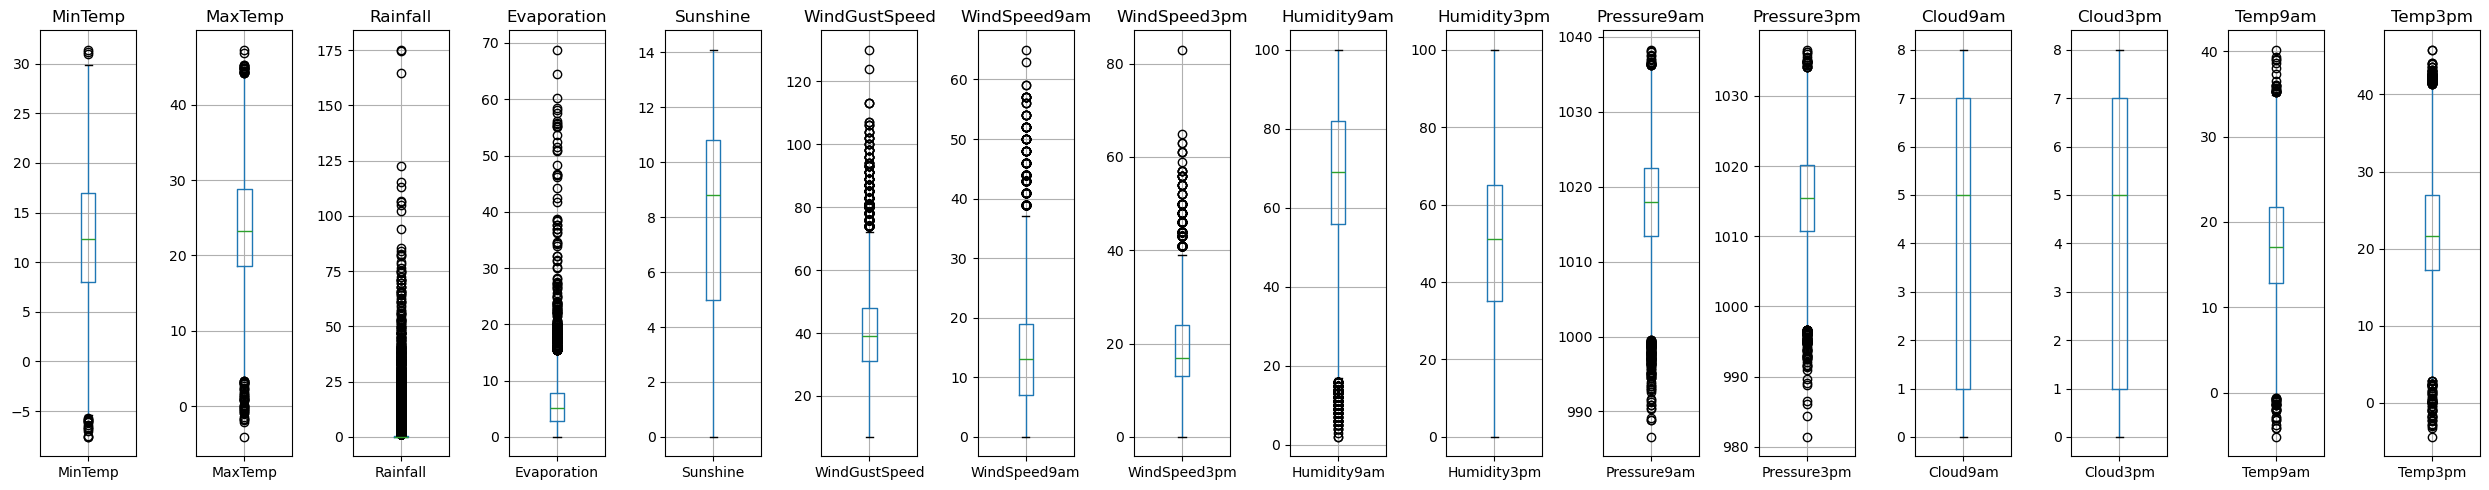

Boxplot pour l année 2015


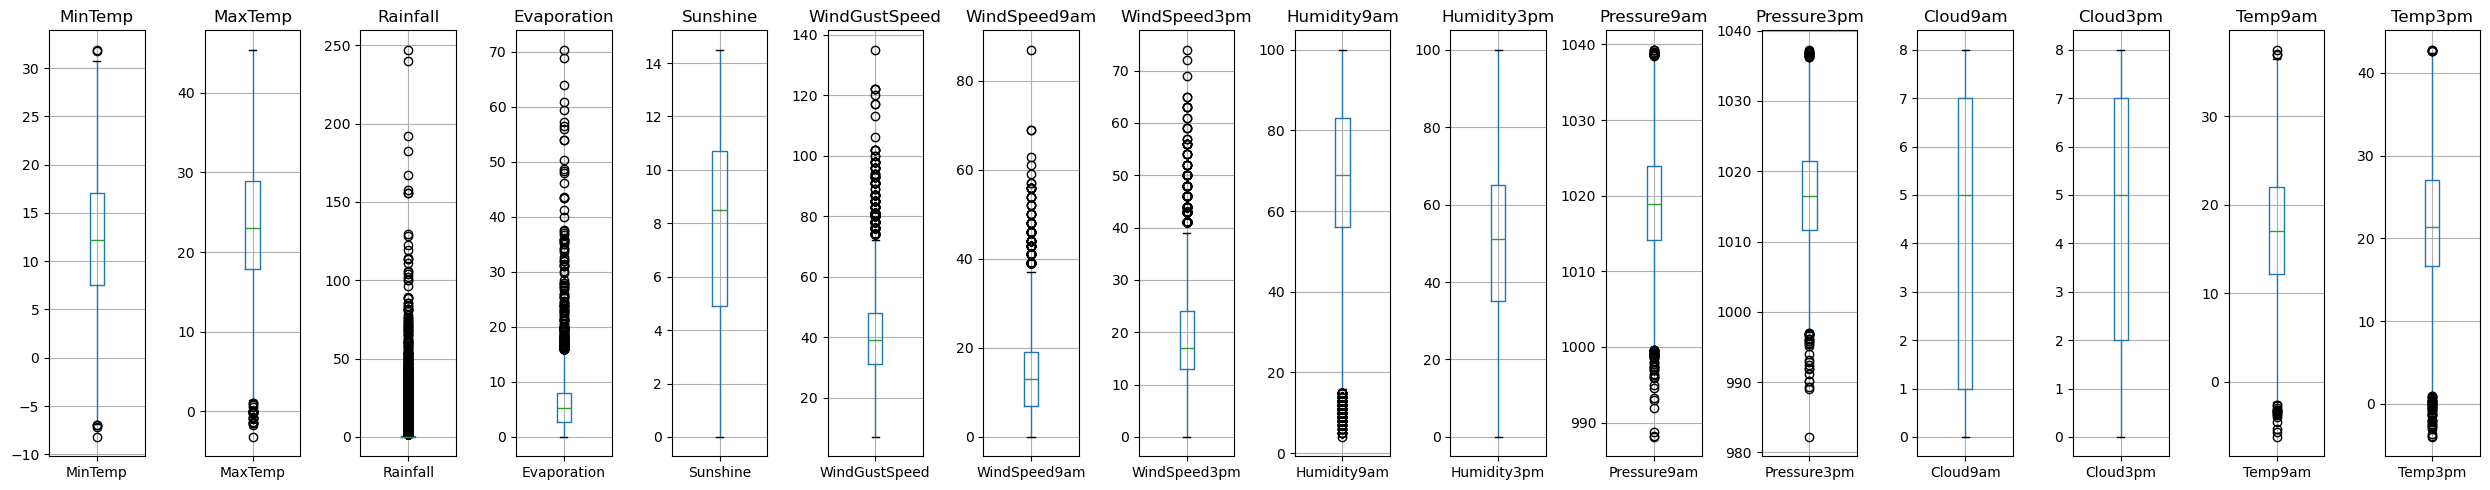

Boxplot pour l année 2016


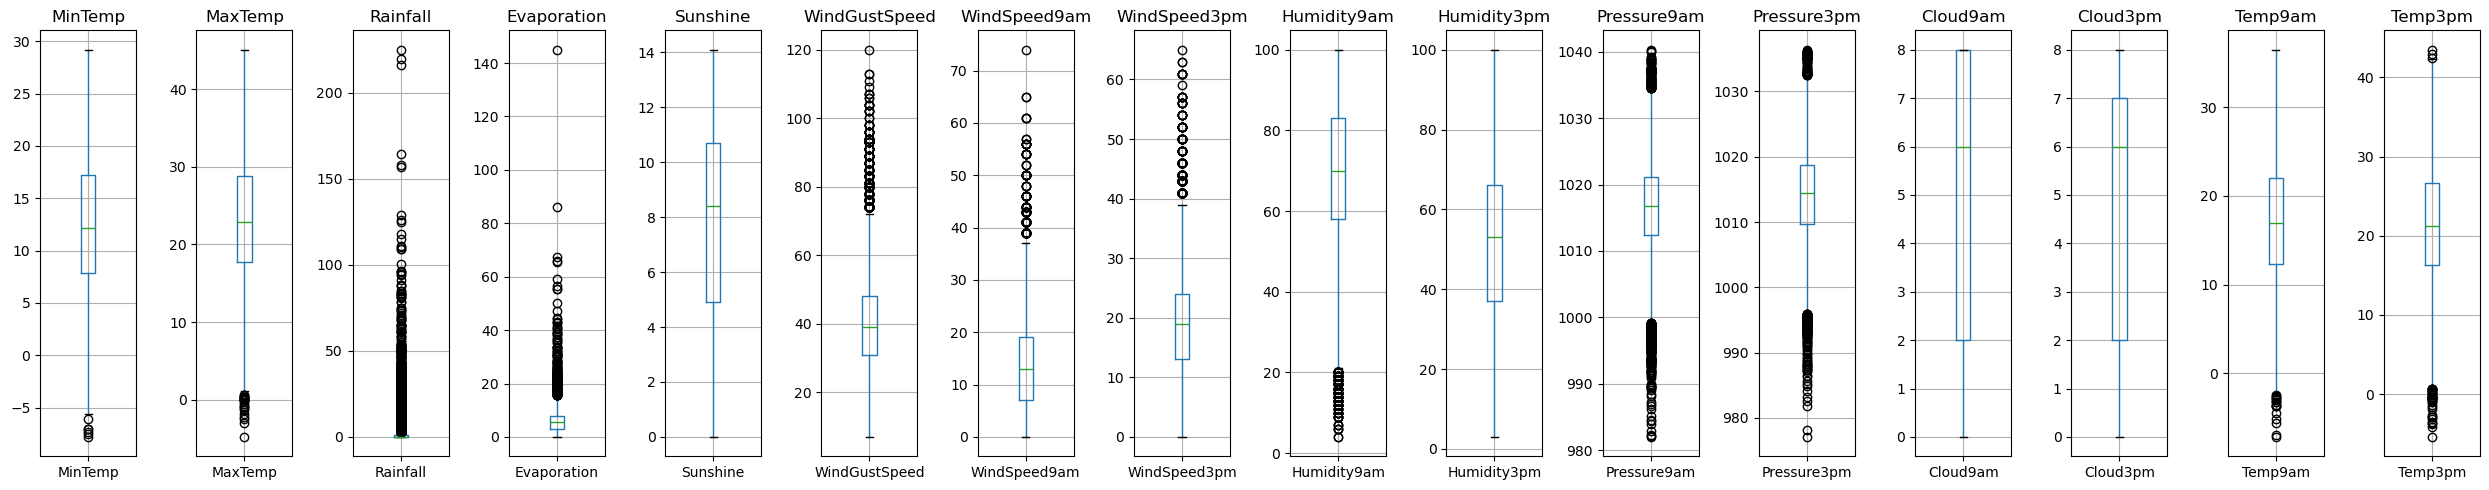

Boxplot pour l année 2017


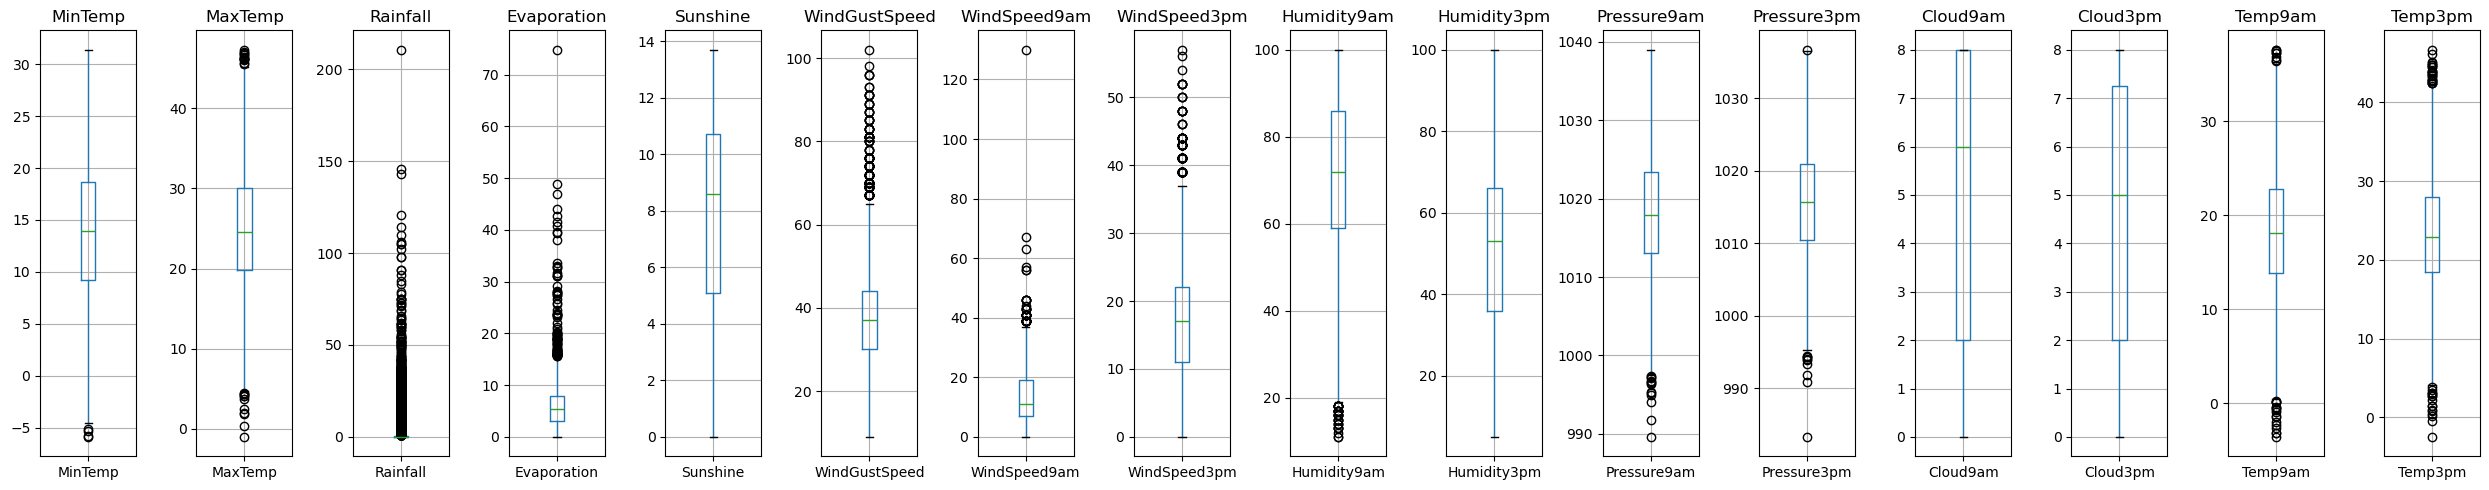

In [13]:
# Boucle 'for' pour tracer les boxplot de chaque colonne numérique en fonction de l'année
# 11 années de relevés, on créé un subplot sur 1 ligne, 16 colonnes pour les  16 numerical_col
# Utilisation de filtre du df sur l'année pour le découpage des subplots 
for j in range (0,11):
    fig, axes = plt.subplots(1, 16, figsize=(25,5))
    print ('Boxplot pour l année',2007 + j)
    df_filtered = df.loc[df['annee'] == 2007 + j]
    for i, col in enumerate(numerical_col):
        df_filtered.boxplot(column=col, ax=axes[i])
        axes[i].set_title(col)
    plt.tight_layout()
    plt.show();

Analyse:<br>
Des valeurs sont en dehors des limites Q1-1.5*IQR et Q3+1.5*IQR, elles sont donc considérées comme des outliers et devraient être supprimées.<br>
<font color="orange">calculer le % de valeur qui apparaissent comme outliers pour chaque année et chaque catégorie afin de visualiser l'impact sur le nbr de relevé de les suppressions</font>

Text(0, 0.5, 'mm de pluie')

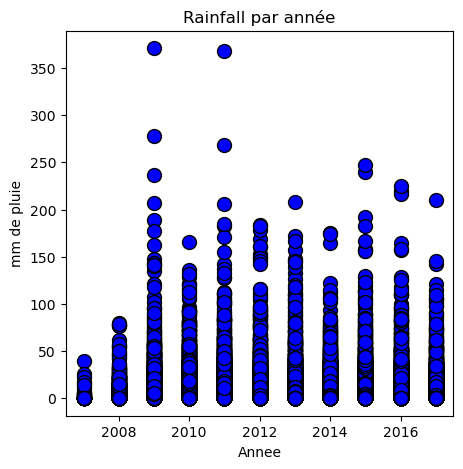

In [14]:
plt.figure(figsize=(5,5))
plt.scatter(df.annee, df.Rainfall, color='blue', s=100, marker='o', edgecolors='black')
plt.title("Rainfall par année")
plt.xlabel("Annee")
plt.ylabel("mm de pluie")

<center><b><font color="skyblue">Recherche de corrélarion</font></b></center>

<font color="orange">Les anlyses ci-dessous sont à reprendre en fonction des décisions sur les données ci-dessus (garde - t-on 2007-2008, gestion des outliers...)</font>

<Axes: >

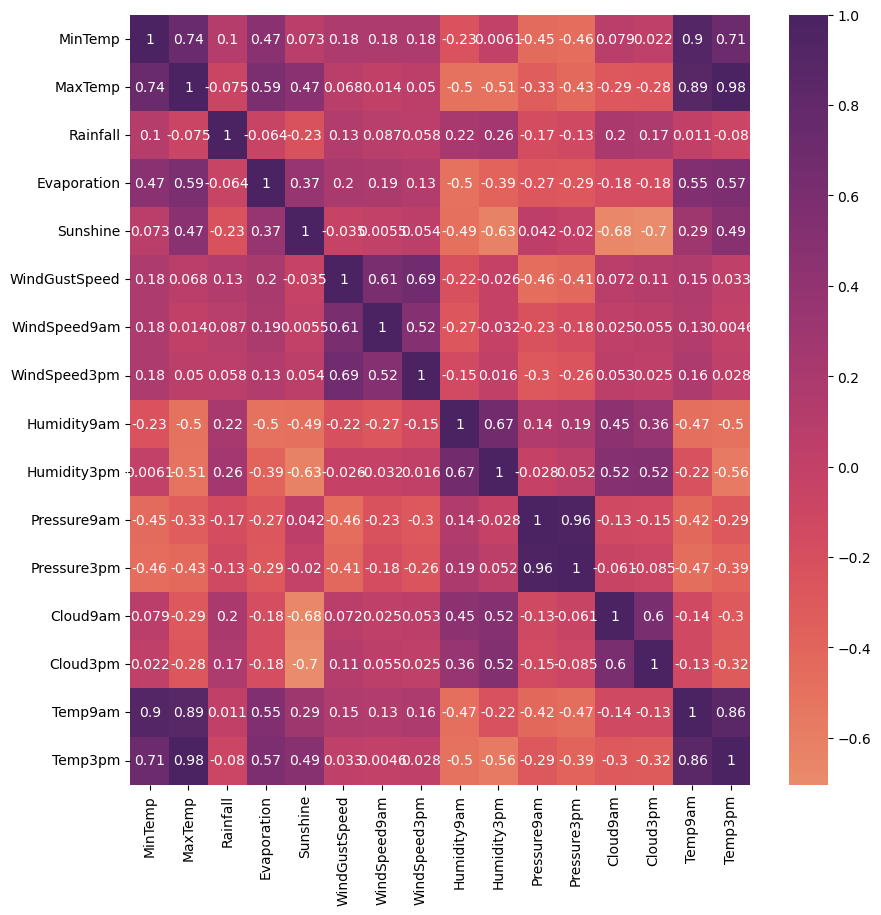

In [15]:
# Recherche s'il y a une corrélation entre 2 variables, utilisation de corr() et de sns.heatmap()
plt.figure(figsize = (10,10))
sns.heatmap(df[numerical_col].corr(), annot = True, cmap = 'flare', center = 0)

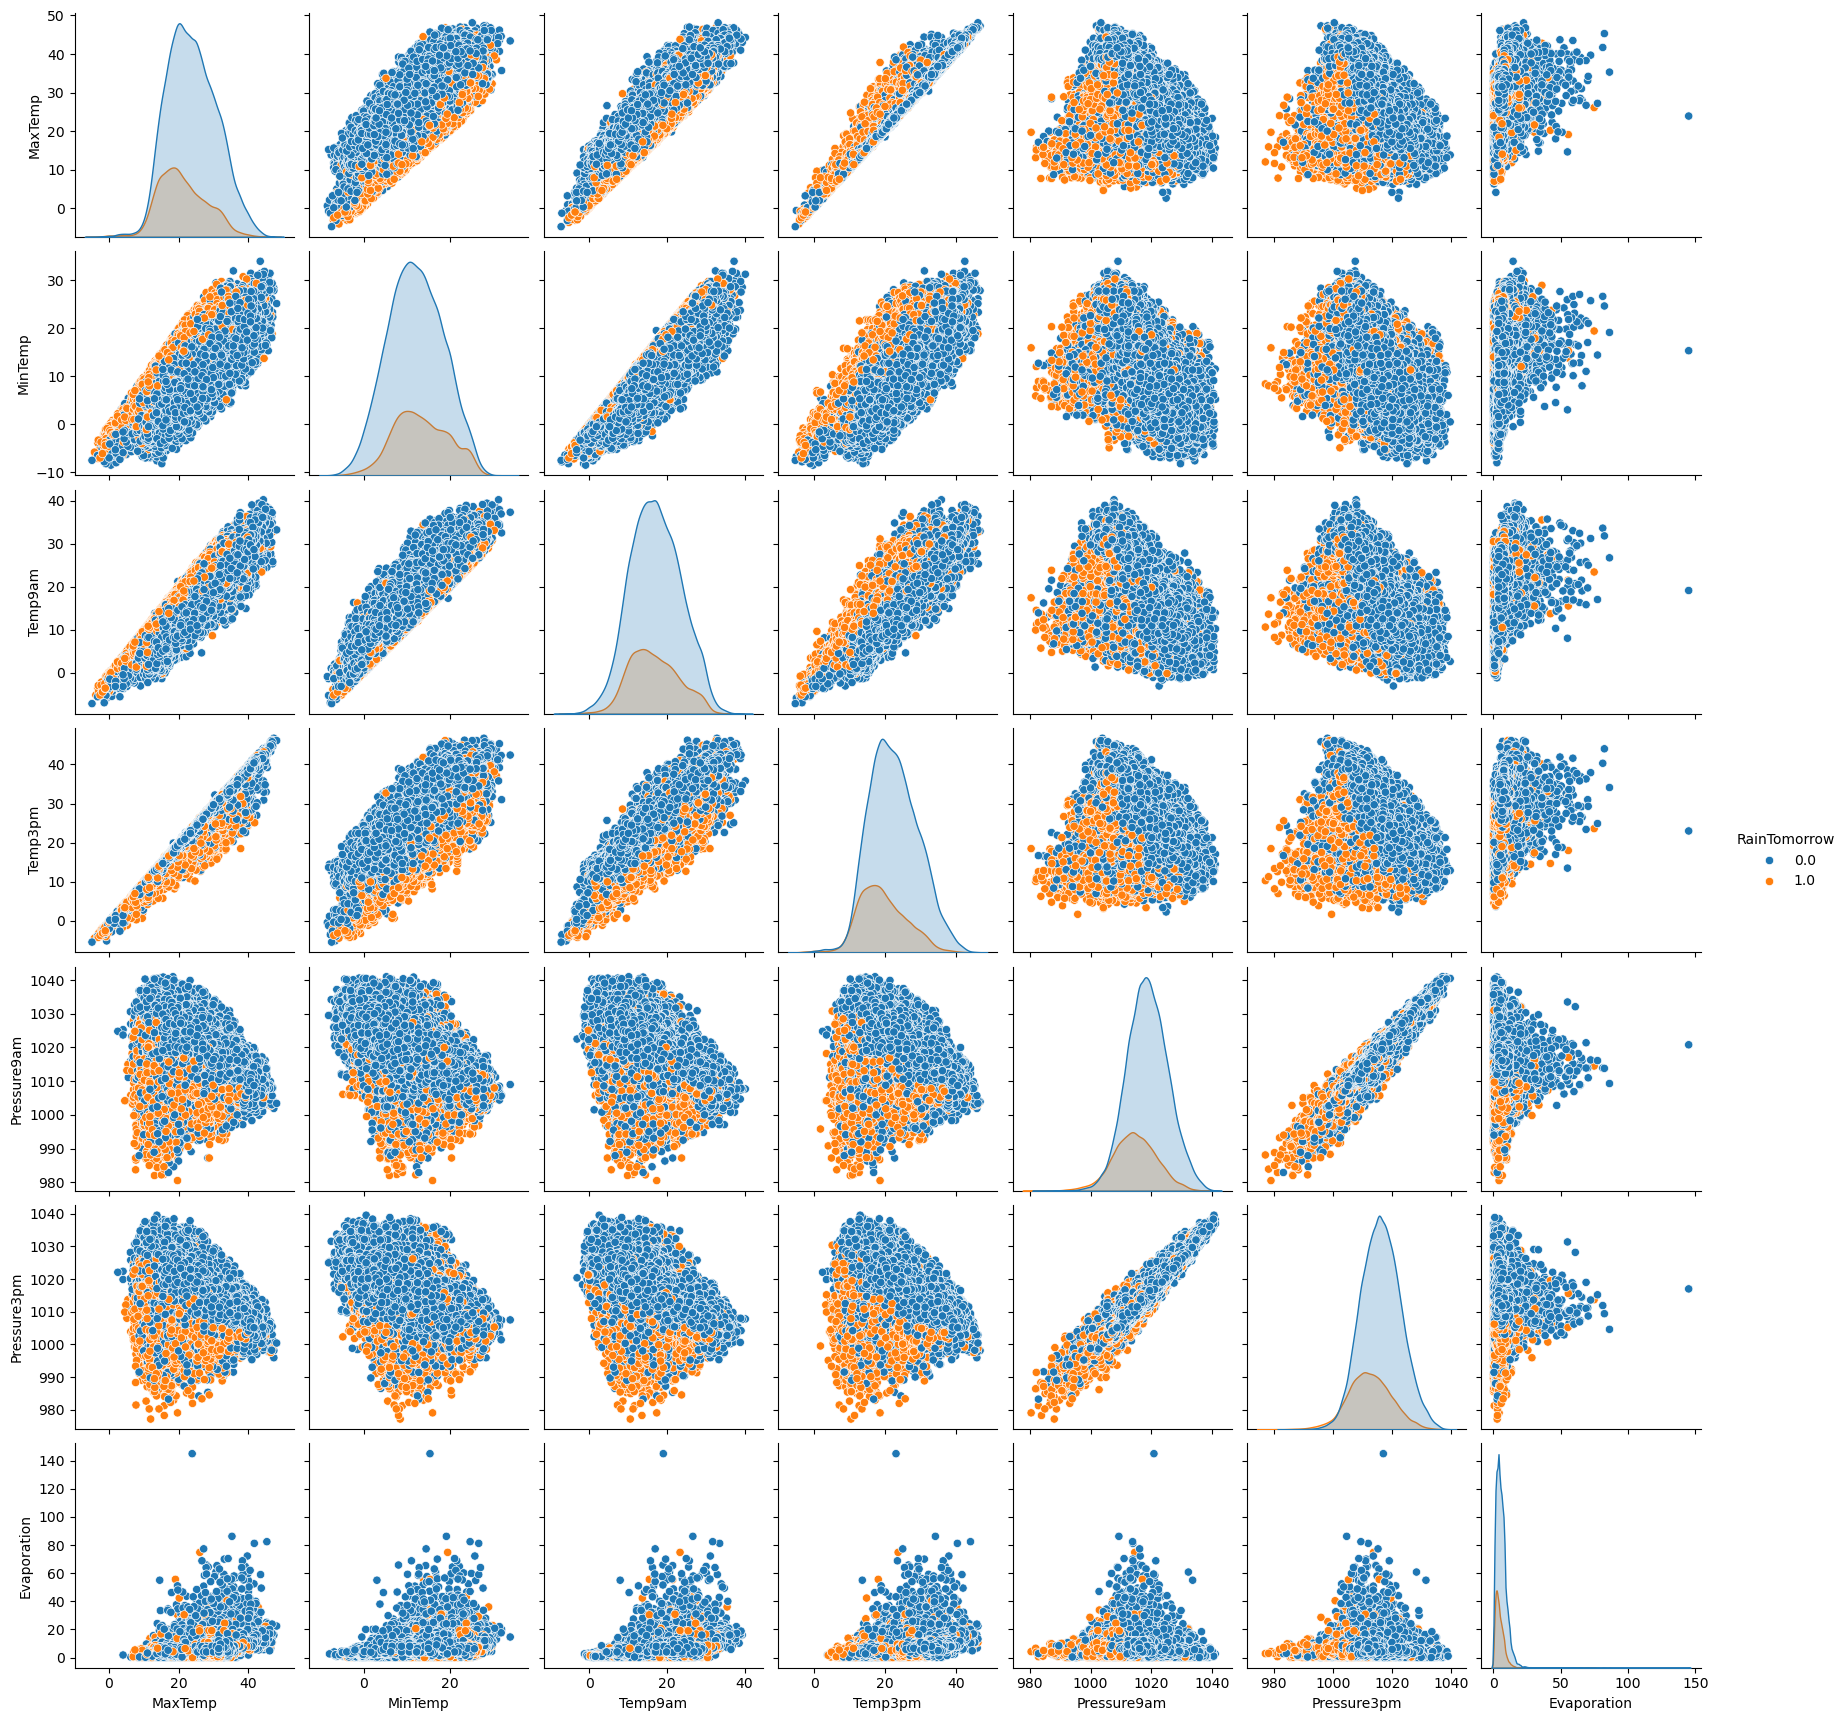

In [16]:
sns.pairplot(df, vars=('MaxTemp','MinTemp', 'Temp9am', 'Temp3pm', 'Pressure9am', 'Pressure3pm', 'Evaporation'), hue='RainTomorrow')
plt.show()

A faire:
get_dummies sur les variables WindGustDir, WindGustDir9am, WindGustDir3pm